# Final Position Scoring Targets (XGBoost)

This notebook builds **position-specific college performance targets** for recruit modeling.

Pipeline:
1. Load per-position college player-year and career files from `aggregated_stats`.
2. Apply position-specific point rubrics (stats, awards, games, SOS).
3. Aggregate to career raw scores and normalize to **0-100** per position.
4. Match scored college players to recruits using `all_matches_combined.csv`.
5. Merge targets into each recruit positional file and save final modeling datasets.

In [99]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path(os.getcwd()).parent

data_dir = PROJECT_ROOT / "data"
college_agg_dir = data_dir / "modeling_datasets" / "college" / "aggregated_stats"
recruit_pos_dir = data_dir / "modeling_datasets" / "recruits" / "positional"
name_match_path = data_dir / "name_matching" / "recruit_college" / "all_matches_combined.csv"
final_output_dir = data_dir / "modeling_datasets" / "final"

final_output_dir.mkdir(parents=True, exist_ok=True)

print(f"College aggregated dir: {college_agg_dir}")
print(f"Recruit positional dir: {recruit_pos_dir}")
print(f"Name match file exists: {name_match_path.exists()}")
print(f"Final output dir: {final_output_dir}")

College aggregated dir: x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\college\aggregated_stats
Recruit positional dir: x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\recruits\positional
Name match file exists: True
Final output dir: x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\final


In [100]:
FINAL_POSITION_GROUPS = ["DB", "EDGE", "IDL", "LB", "OL", "QB", "RB", "SPEC", "TE", "WR"]
OFFENSE_POSITIONS = {"QB", "RB", "WR", "TE", "SPEC"}
DEFENSE_POSITIONS = {"DB", "LB", "EDGE", "IDL"}
OL_POSITIONS = {"OL"}

from scipy.stats import norm

def safe_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").fillna(0)

def normalize_0_100(series: pd.Series) -> pd.Series:
    """
    1. Filters for non-zero values.
    2. Applies a log transform (log1p).
    3. Enforces a normal distribution using rank-based quantile mapping.
    4. Scales results to a 1-100 range.
    5. Re-integrates players with 0 stats as 0.0.
    """
    values = pd.to_numeric(series, errors="coerce").fillna(0)
    mask = values > 2
    active_values = values[mask]

    if active_values.empty:
        return pd.Series([0.0] * len(values), index=values.index)

    log_active = np.log1p(active_values)
    n = len(log_active)
    ranks = log_active.rank(method='average')
    percentiles = (ranks - 0.5) / n
    z_scores = norm.ppf(percentiles)

    if n > 1:
        z_min, z_max = z_scores.min(), z_scores.max()
        scaled_active = ((z_scores - z_min) / (z_max - z_min)) * 99 + 1
    else:
        scaled_active = [100.0]

    result = pd.Series(0.0, index=values.index)
    result.loc[mask] = scaled_active
    return result.round(4)

def normalize_with_games(series: pd.Series, games_series: pd.Series, min_games: int = 2) -> pd.Series:
    normed = normalize_0_100(series)
    games = safe_numeric(games_series)
    normed = normed.where(games > min_games, 0.0)
    return normed.round(4)

def weighted_sum(df: pd.DataFrame, weight_map: dict) -> pd.Series:
    total = pd.Series([0.0] * len(df), index=df.index, dtype=float)
    for column, weight in weight_map.items():
        if column in df.columns:
            total = total + safe_numeric(df[column]) * float(weight)
    return total

def compute_sos_percentile(series: pd.Series) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce")
    if values.notna().sum() == 0:
        return pd.Series([0.5] * len(values), index=values.index, dtype=float)
    pct = values.rank(method="average", pct=True)
    return pct.fillna(0.5).astype(float)

def shrink_per_game(per_game_series: pd.Series, games_series: pd.Series, prior_games: float = 6.0) -> pd.Series:
    per_game = pd.to_numeric(per_game_series, errors="coerce").fillna(0.0)
    games = safe_numeric(games_series)
    active_mask = games > 0
    if active_mask.any():
        prior_value = per_game[active_mask].median()
    else:
        prior_value = 0.0
    shrunk = (games / (games + prior_games)) * per_game + (prior_games / (games + prior_games)) * prior_value
    return shrunk.fillna(0.0)

year_file_map = {position: college_agg_dir / f"{position}_college_player_year_ready.csv" for position in FINAL_POSITION_GROUPS}
career_file_map = {position: college_agg_dir / f"{position}_college_player_career_ready.csv" for position in FINAL_POSITION_GROUPS}

missing_year = [pos for pos, path in year_file_map.items() if not path.exists()]
missing_career = [pos for pos, path in career_file_map.items() if not path.exists()]

print("Missing year files:", missing_year)
print("Missing career files:", missing_career)

Missing year files: []
Missing career files: []


In [101]:
# Position-specific scoring rubrics (edit weights here)
# - year_metric_weights: per-season production
# - career_metric_weights: career-level production only (no seasons_count / games_total)
# - award_binary_weights: optional award_* binary columns
# - award_count_weight: points per award_count
# - heisman_bonus_topN: bonus for career heisman_finish 1..N

RUBRIC_BASE = {
    "year_metric_weights": {},
    "career_metric_weights": {},
    "award_binary_weights": {"award_aa": 15.0},
    "award_count_weight": 10.0,
    "heisman_bonus_topN": {1: 100.0, 2: 80.0, 3: 60.0, 4: 40.0, 5: 30.0, 6: 20.0, 7: 15.0, 9: 10.0, 10: 5.0 },
}

POSITION_RUBRICS = {
    "QB": {
        **RUBRIC_BASE,
        "year_metric_weights": {"pass_yds": 0.02, "pass_td": 1.4, "pass_int": -1.1, "rush_yds": 0.02, "rush_td": 1.0},
        "career_metric_weights": {"pass_yds": 0.01, "pass_td": 1.0, "pass_int": -0.8},
    },
    "RB": {
        **RUBRIC_BASE,
        "year_metric_weights": {"rush_yds": 0.03, "rush_td": 1.5, "rec_yds": 0.02, "rec_td": 1.3},
        "career_metric_weights": {"rush_yds": 0.015, "rush_td": 1.0, "rec_yds": 0.01},
    },
    "WR": {
        **RUBRIC_BASE,
        "year_metric_weights": {"rec_yds": 0.03, "rec_td": 1.6, "rush_yds": 0.01, "rush_td": 0.8},
        "career_metric_weights": {"rec_yds": 0.016, "rec_td": 1.1},
    },
    "TE": {
        **RUBRIC_BASE,
        "year_metric_weights": {"rec_yds": 0.025, "rec_td": 1.4},
        "career_metric_weights": {"rec_yds": 0.014, "rec_td": 1.0},
    },
    "OL": {
        **RUBRIC_BASE,
        "year_metric_weights": {},
        "career_metric_weights": {},
        "award_binary_weights": {"award_aa": 25.0},
        "award_count_weight": 50
    },
    "DB": {
        **RUBRIC_BASE,
        "year_metric_weights": {"def_int": 2.3, "pass_defended": 0.7, "tackles_combined": 0.08},
        "career_metric_weights": {"def_int": 1.6, "pass_defended": 0.5},
    },
    "LB": {
        **RUBRIC_BASE,
        "year_metric_weights": {"tackles_combined": 0.10, "tackles_loss": 0.6, "sacks": 1.5},
        "career_metric_weights": {"tackles_combined": 0.06, "sacks": 1.0},
    },
    "EDGE": {
        **RUBRIC_BASE,
        "year_metric_weights": {"sacks": 1.9, "tackles_loss": 0.8, "tackles_combined": 0.06},
        "career_metric_weights": {"sacks": 1.3, "tackles_loss": 0.5},
    },
    "IDL": {
        **RUBRIC_BASE,
        "year_metric_weights": {"sacks": 1.7, "tackles_loss": 0.7, "tackles_combined": 0.08},
        "career_metric_weights": {"sacks": 1.2, "tackles_loss": 0.45},
    },
    "SPEC": {
        **RUBRIC_BASE,
        "year_metric_weights": {"fgm": 1.2, "xpm": 0.2, "punt_yds": 0.003},
        "career_metric_weights": {"fgm": 0.9, "xpm": 0.15, "punt_yds": 0.002},
    },
}

print("Rubrics loaded for positions:", sorted(POSITION_RUBRICS.keys()))

Rubrics loaded for positions: ['DB', 'EDGE', 'IDL', 'LB', 'OL', 'QB', 'RB', 'SPEC', 'TE', 'WR']


In [102]:
scored_career_by_position = {}

def run_position_scoring(position: str, save_output: bool = True, show_top_n: int = 10) -> pd.DataFrame:
    if position not in FINAL_POSITION_GROUPS:
        raise ValueError(f"Unsupported position: {position}")

    year_path = year_file_map[position]
    career_path = career_file_map[position]
    if not year_path.exists() or not career_path.exists():
        raise FileNotFoundError(f"Missing input files for {position}: {year_path}, {career_path}")

    rubric = POSITION_RUBRICS[position]
    year_df = pd.read_csv(year_path, dtype=str).fillna("")
    career_df = pd.read_csv(career_path, dtype=str).fillna("")

    year_df["Player_ID"] = year_df["Player_ID"].astype(str).str.strip()
    year_df["games_total"] = safe_numeric(year_df.get("games_total", 0))
    year_df["award_count"] = safe_numeric(year_df.get("award_count", 0))
    year_df["heisman_finish"] = pd.to_numeric(year_df.get("heisman_finish", 0), errors="coerce").fillna(0)

    year_metric_score = weighted_sum(year_df, rubric["year_metric_weights"])
    year_award_binary_score = weighted_sum(year_df, rubric.get("award_binary_weights", {}))
    year_award_count_score = year_df["award_count"] * float(rubric["award_count_weight"])
    year_df["year_score_raw"] = year_metric_score + year_award_binary_score + year_award_count_score

    year_rollup = (
        year_df.groupby(["Player_ID"], as_index=False)
        .agg({
            "year_score_raw": "sum",
            "games_total": "sum",
        })
        .rename(columns={"year_score_raw": "year_score_sum", "games_total": "year_games_sum"})
    )

    career_df["Player_ID"] = career_df["Player_ID"].astype(str).str.strip()
    career_df["games_total"] = safe_numeric(career_df.get("games_total", 0))
    career_df["award_count"] = safe_numeric(career_df.get("award_count", 0))
    career_df["heisman_finish"] = pd.to_numeric(career_df.get("heisman_finish", 0), errors="coerce").fillna(0)
    career_df["sos_season_weighted"] = pd.to_numeric(career_df.get("sos_season_weighted", pd.NA), errors="coerce")
    career_df["weighted_sos_percentile"] = compute_sos_percentile(career_df["sos_season_weighted"])
    career_df["sos_multiplier"] = 1.0 + career_df["weighted_sos_percentile"]

    career_df = career_df.merge(year_rollup[["Player_ID", "year_score_sum"]], on="Player_ID", how="left")
    career_df["year_score_sum"] = safe_numeric(career_df.get("year_score_sum", 0))

    career_metric_score = weighted_sum(career_df, rubric["career_metric_weights"])
    career_award_binary_score = weighted_sum(career_df, rubric.get("award_binary_weights", {}))
    career_award_count_score = career_df["award_count"] * float(rubric["award_count_weight"])

    heisman_bonus_map = rubric.get("heisman_bonus_topN", {})
    career_df["heisman_bonus"] = career_df["heisman_finish"].map(
        lambda value: heisman_bonus_map.get(int(value), 0.0) if value > 0 else 0.0
    )

    career_df["base_raw_score"] = (
        career_df["year_score_sum"]
        + career_metric_score
        + career_award_binary_score
        + career_award_count_score
        + career_df["heisman_bonus"]
    )

    games = career_df["games_total"]
    career_df["raw_per_game"] = np.where(games > 0, career_df["base_raw_score"] / games, 0.0)
    career_df["raw_per_game_shrunk"] = shrink_per_game(career_df["raw_per_game"], games, prior_games=6.0)
    career_df["component_pg_sos_raw"] = career_df["raw_per_game_shrunk"] * career_df["sos_multiplier"]
    career_df["component_games_sos_raw"] = games * career_df["sos_multiplier"]

    career_df["component_pg_sos_norm"] = normalize_with_games(career_df["component_pg_sos_raw"], games, min_games=2)
    career_df["component_games_sos_norm"] = normalize_with_games(career_df["component_games_sos_raw"], games, min_games=2)

    if position in OL_POSITIONS:
        career_df["score_blend_pre_norm"] = career_df["component_games_sos_raw"] + career_df["base_raw_score"]
        career_df["career_score_raw"] = career_df["score_blend_pre_norm"]
        career_df["career_score_norm_0_100"] = normalize_with_games(career_df["score_blend_pre_norm"], games, min_games=2)
    elif position in DEFENSE_POSITIONS:
        career_df["score_blend_pre_norm"] = (
            0.50 * career_df["component_pg_sos_norm"]
            + 0.50 * career_df["component_games_sos_norm"]
        )
        career_df["career_score_norm_0_100"] = normalize_with_games(career_df["score_blend_pre_norm"], games, min_games=2)
        career_df["career_score_raw"] = career_df["base_raw_score"]
    elif position in OFFENSE_POSITIONS:
        career_df["score_blend_pre_norm"] = (
            0.50 * career_df["component_pg_sos_norm"]
            + 0.50 * career_df["component_games_sos_norm"]
        )
        career_df["career_score_norm_0_100"] = normalize_with_games(career_df["score_blend_pre_norm"], games, min_games=2)
        career_df["career_score_raw"] = career_df["base_raw_score"]
    else:
        career_df["career_score_raw"] = career_df["base_raw_score"]
        career_df["career_score_norm_0_100"] = normalize_with_games(career_df["career_score_raw"], games, min_games=2)
        career_df["score_blend_pre_norm"] = career_df["career_score_norm_0_100"]

    keep_cols = [
        "Player_ID", "Player", "pos_norm", "latest_school", "schools_played",
        "games_total", "sos_season_weighted", "weighted_sos_percentile", "sos_multiplier",
        "award_count", "awards", "heisman_finish",
        "year_score_sum", "heisman_bonus", "base_raw_score", "career_score_raw",
        "raw_per_game", "raw_per_game_shrunk",
        "component_pg_sos_raw", "component_games_sos_raw",
        "component_pg_sos_norm", "component_games_sos_norm", "score_blend_pre_norm",
        "career_score_norm_0_100",
    ]
    keep_cols = [column for column in keep_cols if column in career_df.columns]
    scored_career = career_df[keep_cols].copy()

    scored_career_by_position[position] = scored_career

    if save_output:
        scored_out_path = final_output_dir / f"{position}_college_scored_targets.csv"
        scored_career.sort_values(["career_score_norm_0_100", "career_score_raw"], ascending=[False, False]).to_csv(
            scored_out_path, index=False, encoding="utf-8-sig"
        )

    print(f"\n=== {position} score summary (raw) ===")
    print(scored_career["career_score_raw"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(3))

    print(f"\n=== {position} score summary (normalized 0-100) ===")
    print(scored_career["career_score_norm_0_100"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(3))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    scored_career["career_score_raw"].plot(kind="hist", bins=30, ax=axes[0], alpha=0.8)
    axes[0].set_title(f"{position} Career Score Raw Distribution")
    axes[0].set_xlabel("career_score_raw")
    axes[0].set_ylabel("count")

    scored_career["career_score_norm_0_100"].plot(kind="hist", bins=30, ax=axes[1], alpha=0.8)
    axes[1].set_title(f"{position} Career Score Norm (0-100) Distribution")
    axes[1].set_xlabel("career_score_norm_0_100")
    axes[1].set_ylabel("count")

    plt.tight_layout()
    plt.show()

    print(f"\n=== {position} top {show_top_n} players ===")
    display_cols = [
        "Player_ID", "Player", "schools_played", "games_total", "award_count",
        "heisman_finish", "career_score_raw", "career_score_norm_0_100",
        "component_pg_sos_norm", "component_games_sos_norm", "score_blend_pre_norm"
    ]
    display_cols = [column for column in display_cols if column in scored_career.columns]
    display(
        scored_career
        .sort_values(["career_score_norm_0_100", "career_score_raw"], ascending=[False, False])[display_cols]
        .head(show_top_n)
    )

    return scored_career


=== QB score summary (raw) ===
count    3357.000
mean       56.863
std       126.099
min        -7.390
10%         0.000
25%         0.000
50%         0.100
75%        40.250
90%       214.408
max      1060.320
Name: career_score_raw, dtype: float64

=== QB score summary (normalized 0-100) ===
count    3357.000
mean       25.047
std        27.219
min         0.000
10%         0.000
25%         0.000
50%         0.000
75%        50.348
90%        62.545
max       100.000
Name: career_score_norm_0_100, dtype: float64


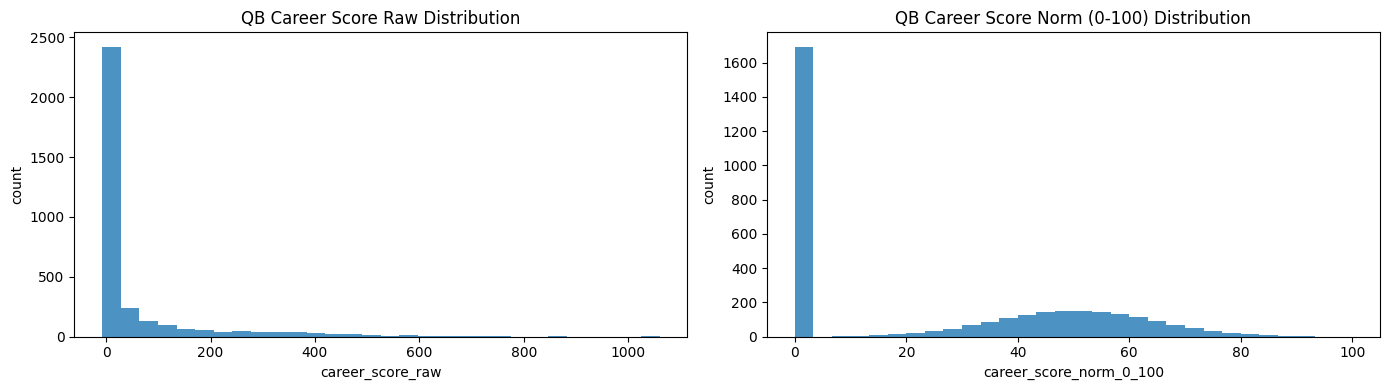


=== QB top 10 players ===


,Player_ID,Player,schools_played,games_total,award_count,heisman_finish,career_score_raw,career_score_norm_0_100,component_pg_sos_norm,component_games_sos_norm,score_blend_pre_norm
2,bo-nix-1,Bo Nix,Auburn|Oregon,61.0,2.0,3,852.59,100.0000,84.9438,100.0000,92.47190
0,dillon-gabriel-1,Dillon Gabriel,Oklahoma|Oregon|UCF,64.0,2.0,3,1030.04,95.5244,84.6843,93.3988,89.04155
156,baker-mayfield-1,Baker Mayfield,Oklahoma,40.0,14.0,1,1060.32,93.3077,100.0000,73.7943,86.89715
15,will-rogers-1,Will Rogers,Mississippi State|Washington,54.0,0.0,0,629.99,91.7928,81.7631,91.9062,86.83465
12,carson-beck-1,Carson Beck,Georgia|Miami (FL),55.0,0.0,0,514.91,90.6302,77.1337,95.5842,86.35895
11,jayden-daniels-1,Jayden Daniels,Arizona State|LSU,55.0,10.0,1,988.21,89.6813,86.8290,84.0330,85.43100
65,michael-penix-jr-1,Michael Penix Jr.,Indiana|Washington,48.0,4.0,2,756.33,88.8766,86.4653,81.7522,84.10875
4,sam-hartman-1,Sam Hartman,Notre Dame|Wake Forest,60.0,0.0,0,737.74,88.1761,79.0536,88.3455,83.69955
48,will-howard-2,Will Howard,Kansas State|Ohio State,50.0,0.0,0,475.52,87.5546,77.2880,89.0348,83.16140
24,payton-thorne-1,Payton Thorne,Auburn|Michigan State,53.0,0.0,0,485.89,86.9951,75.6215,89.8268,82.72415


In [103]:
# QB scoring (iterate here first)
QB_SCORED = run_position_scoring("QB", save_output=True, show_top_n=10)


=== RB score summary (raw) ===
count    5307.000
mean       34.344
std        64.891
min        -0.270
10%         0.000
25%         0.000
50%         2.115
75%        37.888
90%       121.117
max       636.540
Name: career_score_raw, dtype: float64

=== RB score summary (normalized 0-100) ===
count    5307.000
mean       31.811
std        26.695
min         0.000
10%         0.000
25%         0.000
50%        39.282
75%        54.076
90%        64.177
max       100.000
Name: career_score_norm_0_100, dtype: float64


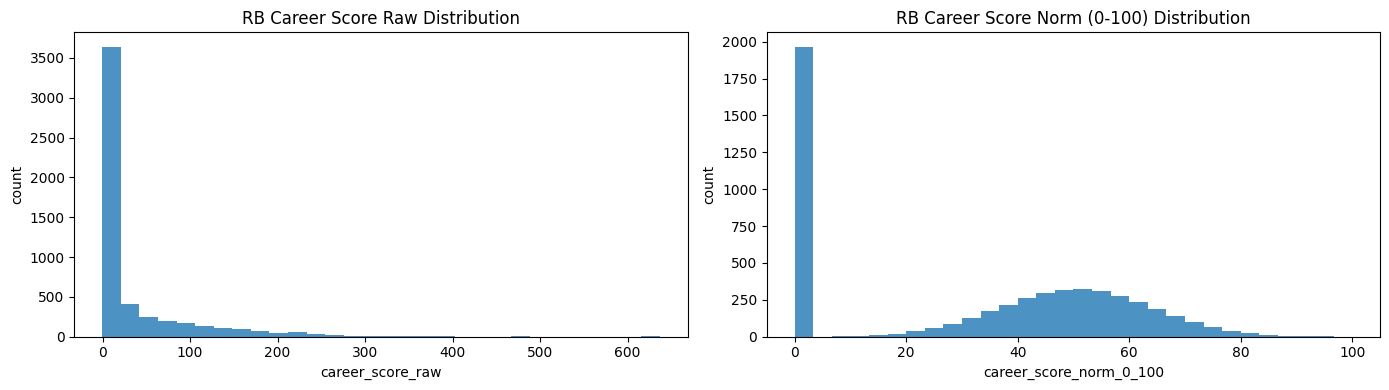


=== RB top 10 players ===


,Player_ID,Player,schools_played,games_total,award_count,heisman_finish,career_score_raw,career_score_norm_0_100,component_pg_sos_norm,component_games_sos_norm,score_blend_pre_norm
53,travis-etienne-1,Travis Etienne,Clemson,55.0,7.0,7,627.890,100.0000,87.3490,84.9068,86.12790
36,joquavious-marks-1,Jo'quavious Marks,Mississippi State|USC,57.0,0.0,0,266.100,95.9592,69.8395,95.9884,82.91395
163,bryce-love-1,Bryce Love,Stanford,49.0,5.0,2,475.520,93.9696,84.5423,79.7314,82.13685
75,kaytron-allen-1,Kaytron Allen,Penn State,54.0,0.0,0,305.500,92.6152,74.0480,88.0025,81.02525
419,jonathan-taylor-1,Jonathan Taylor,Wisconsin,41.0,7.0,5,636.540,91.5787,91.6631,70.0142,80.83865
89,nicholas-singleton-1,Nicholas Singleton,Penn State,53.0,0.0,0,309.555,90.7348,75.4011,86.2272,80.81415
29,roman-hemby-1,Roman Hemby,Indiana|Maryland,58.0,0.0,0,267.595,90.0207,68.2604,92.6703,80.46535
51,tahj-brooks-1,Tahj Brooks,Texas Tech,56.0,0.0,0,336.605,89.4003,74.1380,85.9354,80.03670
251,treveyon-henderson-1,TreVeyon Henderson,Ohio State,47.0,0.0,0,307.635,88.8508,78.7121,81.1316,79.92185
103,myles-gaskin-1,Myles Gaskin,Washington,52.0,0.0,0,402.485,88.3569,80.1046,79.1770,79.64080


In [104]:
# RB scoring
RB_SCORED = run_position_scoring("RB", save_output=True, show_top_n=10)


=== WR score summary (raw) ===
count    9492.000
mean       21.404
std        42.592
min        -0.322
10%         0.000
25%         0.000
50%         0.276
75%        20.616
90%        80.124
max       637.450
Name: career_score_raw, dtype: float64

=== WR score summary (normalized 0-100) ===
count    9492.000
mean       29.554
std        26.857
min         0.000
10%         0.000
25%         0.000
50%        36.553
75%        52.924
90%        63.061
max       100.000
Name: career_score_norm_0_100, dtype: float64


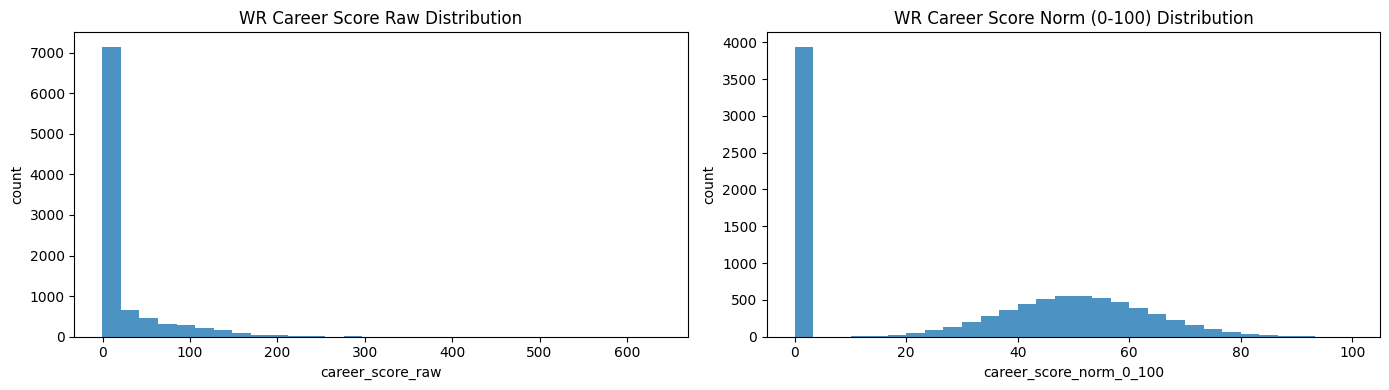


=== WR top 10 players ===


,Player_ID,Player,schools_played,games_total,award_count,heisman_finish,career_score_raw,career_score_norm_0_100,component_pg_sos_norm,component_games_sos_norm,score_blend_pre_norm
153,devonta-smith-1,DeVonta Smith,Alabama,54.0,10.0,1,637.450,100.0000,93.3007,71.5333,82.41700
993,marvin-harrison-jr-1,Marvin Harrison Jr.,Ohio State,38.0,5.0,4,390.278,96.2274,95.5198,67.4551,81.48745
6,brennan-presley-1,Brennan Presley,Oklahoma State,64.0,0.0,0,220.990,94.3767,67.2849,92.0402,79.66255
1900,dede-westbrook-1,Dede Westbrook,Oklahoma,26.0,4.0,4,312.162,93.1197,100.0000,58.1300,79.06500
815,ceedee-lamb-1,CeeDee Lamb,Oklahoma,41.0,1.0,0,288.832,92.1595,86.4705,69.5437,78.00710
18,theo-wease-1,Theo Wease,Missouri|Oklahoma,63.0,0.0,0,173.960,91.3789,60.8199,93.0144,76.91715
508,chris-olave-1,Chris Olave,Ohio State,47.0,0.0,0,219.256,90.7192,77.6617,76.0225,76.84210
1676,jeremiah-smith-2,Jeremiah Smith,Ohio State,29.0,2.0,6,282.848,90.1466,91.7841,61.8068,76.79545
378,emeka-egbuka-1,Emeka Egbuka,Ohio State,49.0,0.0,0,199.778,89.6400,74.0071,79.4813,76.74420
996,malik-nabers-1,Malik Nabers,LSU,38.0,1.0,0,245.128,89.1852,85.1631,67.3427,76.25290


In [105]:
# WR scoring
WR_SCORED = run_position_scoring("WR", save_output=True, show_top_n=10)


=== TE score summary (raw) ===
count    4116.000
mean        8.459
std        19.490
min        -0.078
10%         0.000
25%         0.000
50%         0.000
75%         6.759
90%        28.633
max       251.382
Name: career_score_raw, dtype: float64

=== TE score summary (normalized 0-100) ===
count    4116.000
mean       30.379
std        27.003
min         0.000
10%         0.000
25%         0.000
50%        37.083
75%        53.480
90%        64.052
max       100.000
Name: career_score_norm_0_100, dtype: float64


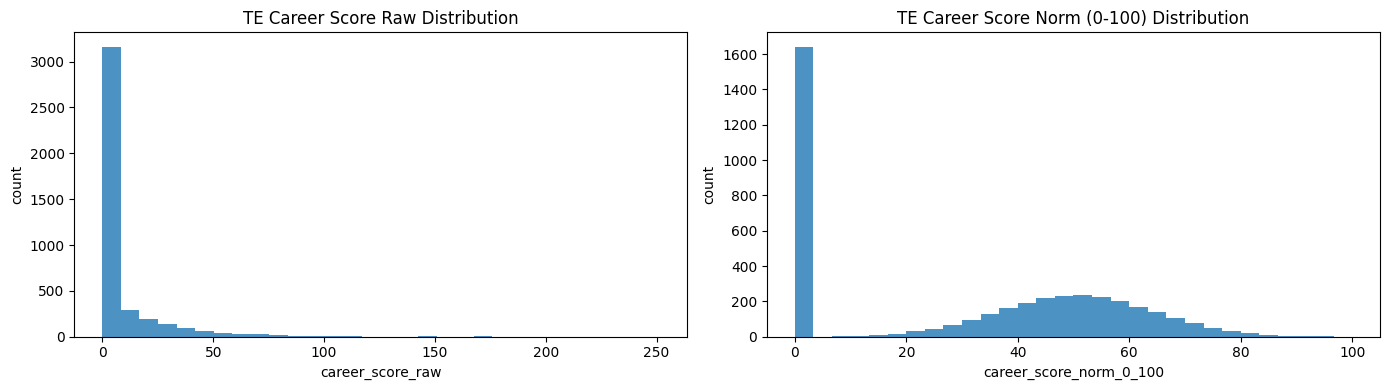


=== TE top 10 players ===


,Player_ID,Player,schools_played,games_total,award_count,heisman_finish,career_score_raw,career_score_norm_0_100,component_pg_sos_norm,component_games_sos_norm,score_blend_pre_norm
42,tyler-warren-1,Tyler Warren,Penn State,55.0,2.0,7,172.321,100.0000,79.5946,87.9152,83.75490
329,brock-bowers-1,Brock Bowers,Georgia,40.0,3.0,0,251.382,95.7824,93.2934,71.8054,82.54940
626,kyle-pitts-1,Kyle Pitts,Florida,32.0,3.0,10,196.388,93.7009,89.8702,64.4222,77.14620
135,charlie-kolar-1,Charlie Kolar,Iowa State,49.0,0.0,0,140.259,92.2815,75.7682,77.6336,76.70090
1410,hunter-henry-1,Hunter Henry,Arkansas,13.0,2.0,0,106.021,91.1941,100.0000,51.3730,75.68650
752,mark-andrews-1,Mark Andrews,Oklahoma,27.0,2.0,0,155.764,90.3080,87.4832,61.2653,74.37425
481,michael-mayer-1,Michael Mayer,Notre Dame,36.0,1.0,0,175.061,89.5574,82.7564,64.9820,73.86920
134,brycen-hopkins-1,Brycen Hopkins,Purdue,49.0,0.0,0,114.255,88.9048,67.9482,78.7877,73.36795
751,eli-stowers-1,Eli Stowers,Texas A&M|Vanderbilt,27.0,2.0,0,146.473,88.3264,85.6212,60.4230,73.02210
794,jake-butt-1,Jake Butt,Michigan,26.0,2.0,0,133.600,87.8062,84.0800,60.5090,72.29450


In [106]:
# TE scoring
TE_SCORED = run_position_scoring("TE", save_output=True, show_top_n=10)


=== OL score summary (raw) ===
count    10260.000
mean        16.851
std         24.548
min          0.000
10%          0.000
25%          0.000
50%          5.830
75%         24.900
90%         51.401
max        431.525
Name: career_score_raw, dtype: float64

=== OL score summary (normalized 0-100) ===
count    10260.000
mean        28.667
std         27.434
min          0.000
10%          0.000
25%          0.000
50%         36.947
75%         53.001
90%         63.041
max        100.000
Name: career_score_norm_0_100, dtype: float64


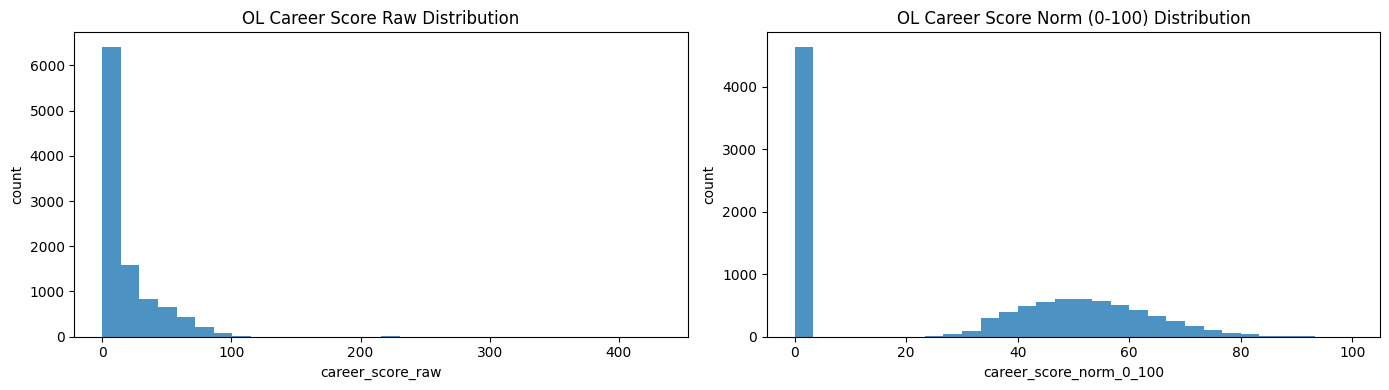


=== OL top 10 players ===


,Player_ID,Player,schools_played,games_total,award_count,heisman_finish,career_score_raw,career_score_norm_0_100,component_pg_sos_norm,component_games_sos_norm,score_blend_pre_norm
477,kelvin-banks-jr-1,Kelvin Banks Jr.,Texas,41.0,3.0,0,431.524655,100.0000,82.2050,76.7033,431.524655
478,garrett-bradbury-1,Garrett Bradbury,North Carolina State,41.0,2.0,0,319.364250,96.2687,60.2675,70.7542,319.364250
568,tyler-biadasz-1,Tyler Biadasz,Wisconsin,39.0,2.0,0,318.310097,94.4393,62.6184,70.1670,318.310097
1522,billy-price-1,Billy Price,Ohio State,27.0,2.0,0,302.502201,93.1972,77.6132,63.5201,302.502201
1384,landon-dickerson-1,Landon Dickerson,Alabama|Florida State,29.0,2.0,0,297.564426,92.2486,70.6390,61.6874,297.564426
2176,penei-sewell-1,Penei Sewell,Oregon,21.0,2.0,0,284.335339,91.4777,88.4746,56.6499,284.335339
2727,ryan-kelly-1,Ryan Kelly,Alabama,15.0,2.0,0,272.356912,90.8262,100.0000,51.7062,272.356912
55,mitch-hyatt-1,Mitch Hyatt,Clemson,54.0,1.0,0,255.123276,90.2610,33.2516,96.2686,255.123276
182,cooper-beebe-1,Cooper Beebe,Kansas State,48.0,1.0,0,240.125037,89.7609,38.3816,81.4030,240.125037
389,carter-snith-1,Carter Smith,Indiana,43.0,1.0,0,230.238480,89.3119,42.9898,75.7762,230.238480


In [107]:
# OL scoring
OL_SCORED = run_position_scoring("OL", save_output=True, show_top_n=10)


=== EDGE score summary (raw) ===
count    2831.000
mean       16.262
std        30.039
min         0.000
10%         0.000
25%         0.000
50%         1.900
75%        20.595
90%        49.470
max       388.790
Name: career_score_raw, dtype: float64

=== EDGE score summary (normalized 0-100) ===
count    2831.000
mean       33.447
std        26.567
min         0.000
10%         0.000
25%         0.000
50%        40.637
75%        54.956
90%        65.240
max       100.000
Name: career_score_norm_0_100, dtype: float64


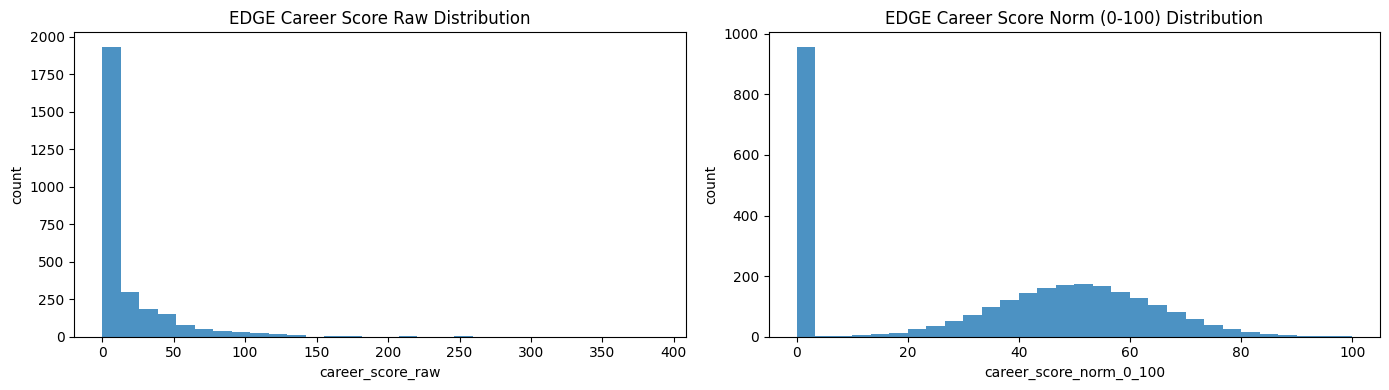


=== EDGE top 10 players ===


,Player_ID,Player,schools_played,games_total,award_count,heisman_finish,career_score_raw,career_score_norm_0_100,component_pg_sos_norm,component_games_sos_norm,score_blend_pre_norm
228,chase-young-1,Chase Young,Ohio State,36.0,8.0,4,388.79,100.0000,94.3953,74.1137,84.25450
99,clelin-ferrell-1,Clelin Ferrell,Clemson,45.0,3.0,0,251.30,95.6048,84.9097,82.2088,83.55925
193,bradley-chubb-1,Bradley Chubb,North Carolina State,38.0,5.0,0,303.20,93.4303,86.8886,71.2463,79.06745
65,donovan-ezeiruaku-1,Donovan Ezeiruaku,Boston College,48.0,3.0,0,258.05,91.9453,81.4462,76.3236,78.88490
157,kenny-willekes-1,Kenny Willekes,Michigan State,40.0,0.0,0,163.24,90.8062,79.8993,77.7686,78.83395
419,demarcus-walker-1,Demarcus Walker,Florida State,26.0,2.0,0,210.46,89.8770,89.6307,64.2389,76.93480
17,jack-sawyer-2,Jack Sawyer,Ohio State,54.0,0.0,0,119.29,89.0893,62.7173,89.9506,76.33395
943,carl-nassib-1,Carl Nassib,Penn State,13.0,5.0,0,207.71,88.4039,100.0000,52.5346,76.26730
168,aj-epenesa-1,A.J. Epenesa,Iowa,39.0,0.0,0,138.31,87.7959,75.7622,76.1376,75.94990
195,brian-burns-2,Brian Burns,Florida State,38.0,0.0,0,135.59,87.2487,76.0740,75.6043,75.83915


In [108]:
# EDGE scoring
EDGE_SCORED = run_position_scoring("EDGE", save_output=True, show_top_n=10)


=== LB score summary (raw) ===
count    8899.000
mean       13.777
std        24.713
min         0.000
10%         0.000
25%         0.000
50%         1.260
75%        17.930
90%        47.636
max       491.250
Name: career_score_raw, dtype: float64

=== LB score summary (normalized 0-100) ===
count    8899.000
mean       32.029
std        26.499
min         0.000
10%         0.000
25%         0.000
50%        39.929
75%        54.042
90%        63.752
max       100.000
Name: career_score_norm_0_100, dtype: float64


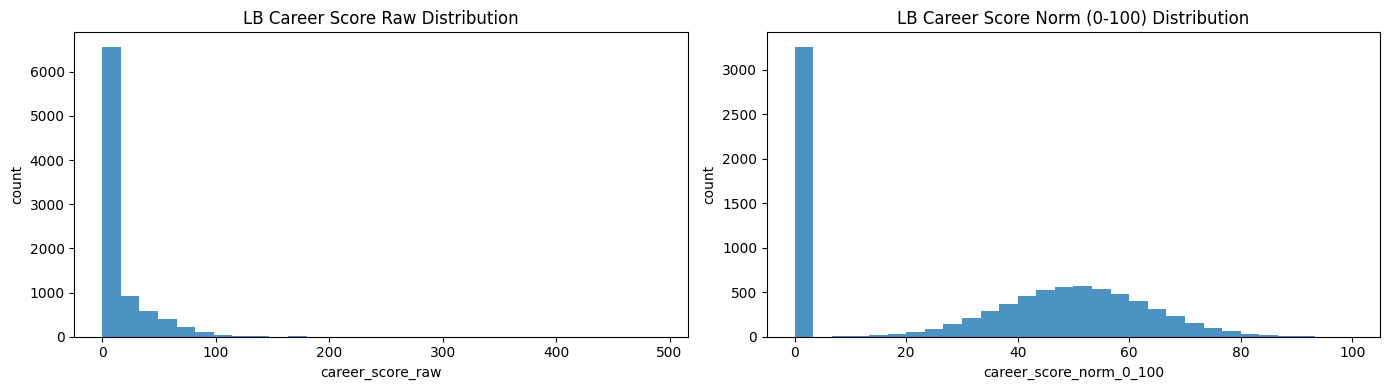


=== LB top 10 players ===


,Player_ID,Player,schools_played,games_total,award_count,heisman_finish,career_score_raw,career_score_norm_0_100,component_pg_sos_norm,component_games_sos_norm,score_blend_pre_norm
702,jacob-rodriguez-1,Jacob Rodriguez,Texas Tech,44.0,9.0,5,320.86,100.0000,90.7728,69.3433,80.05805
267,josh-allen-6,Josh Allen,Kentucky,51.0,7.0,0,308.39,96.2352,86.6440,73.1175,79.88075
115,nathaniel-watson-1,Nathaniel Watson,Mississippi State,57.0,0.0,0,134.14,94.3886,73.8612,84.6945,79.27785
844,will-anderson-jr-1,Will Anderson Jr.,Alabama,41.0,13.0,5,491.25,93.1344,94.9892,63.4714,79.23030
450,david-bailey-5,David Bailey,Stanford|Texas Tech,48.0,1.0,0,173.78,92.1764,80.8691,74.8035,77.83630
512,danny-stutsman-1,Danny Stutsman,Oklahoma,47.0,1.0,0,151.76,91.3976,79.6426,74.9289,77.28575
803,abdul-carter-1,Abdul Carter,Penn State,42.0,2.0,0,178.72,90.7395,83.6531,70.4311,77.04210
578,payton-wilson-1,Payton Wilson,North Carolina State,46.0,5.0,0,260.62,90.1683,85.9295,67.4737,76.70160
902,roquan-smith-1,Roquan Smith,Georgia,40.0,4.0,10,183.87,89.6630,84.1553,67.3445,75.74990
1,nick-jackson-2,Nick Jackson,Iowa|Virginia,73.0,0.0,0,151.10,89.2092,62.3742,88.8466,75.61040


In [109]:
# LB scoring
LB_SCORED = run_position_scoring("LB", save_output=True, show_top_n=10)


=== DB score summary (raw) ===
count    12036.000
mean        11.606
std         19.631
min          0.000
10%          0.000
25%          0.000
50%          1.040
75%         16.410
90%         39.290
max        436.780
Name: career_score_raw, dtype: float64

=== DB score summary (normalized 0-100) ===
count    12036.000
mean        33.759
std         26.008
min          0.000
10%          0.000
25%          0.000
50%         41.883
75%         54.642
90%         63.889
max        100.000
Name: career_score_norm_0_100, dtype: float64


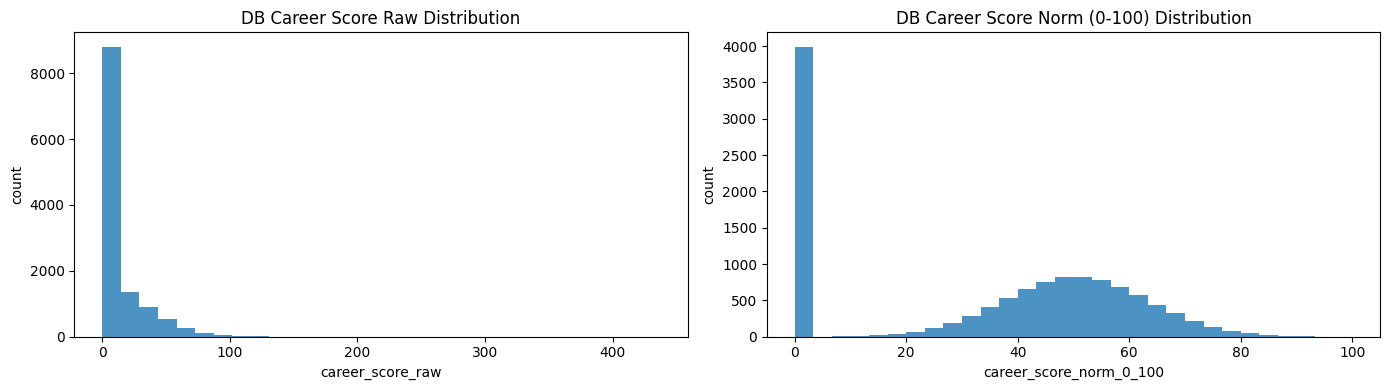


=== DB top 10 players ===


,Player_ID,Player,schools_played,games_total,award_count,heisman_finish,career_score_raw,career_score_norm_0_100,component_pg_sos_norm,component_games_sos_norm,score_blend_pre_norm
139,jahdae-barron-1,Jahdae Barron,Texas,57.0,2.0,0,148.08,100.0000,76.2708,87.3010,81.78590
1058,caleb-downs-1,Caleb Downs,Alabama|Ohio State,44.0,6.0,9,233.36,96.4021,92.0377,70.6425,81.34010
1228,xavier-watts-1,Xavier Watts,Notre Dame,42.0,4.0,0,211.14,94.6414,90.2084,68.2880,79.24820
2880,adoree-jackson-1,Adoree Jackson,USC,27.0,4.0,0,163.40,93.4472,94.6950,58.9145,76.80475
3884,travis-hunter-2,Travis Hunter,Colorado,22.0,12.0,1,436.78,92.5361,100.0000,52.9847,76.49235
172,christopher-smith-1,Christopher Smith,Georgia,56.0,1.0,0,95.96,91.7961,65.8898,85.1300,75.50990
1227,minkah-fitzpatrick-1,Minkah Fitzpatrick,Alabama,42.0,5.0,0,224.98,91.1712,86.6516,62.4935,74.57255
1398,grant-delpit-1,Grant Delpit,LSU,40.0,3.0,0,180.92,90.6292,82.5687,64.6317,73.60020
1596,julian-love-1,Julian Love,Notre Dame,38.0,1.0,0,130.38,90.1501,80.3070,66.6788,73.49290
226,jr-reed-3,J.R. Reed,Georgia|Tulsa,55.0,1.0,0,103.82,89.7200,66.9878,79.9280,73.45790


In [110]:
# DB scoring
DB_SCORED = run_position_scoring("DB", save_output=True, show_top_n=10)


=== IDL score summary (raw) ===
count    7843.000
mean       13.145
std        22.683
min         0.000
10%         0.000
25%         0.000
50%         2.265
75%        17.455
90%        40.187
max       333.725
Name: career_score_raw, dtype: float64

=== IDL score summary (normalized 0-100) ===
count    7843.000
mean       33.546
std        26.188
min         0.000
10%         0.000
25%         0.000
50%        41.435
75%        54.681
90%        64.222
max       100.000
Name: career_score_norm_0_100, dtype: float64


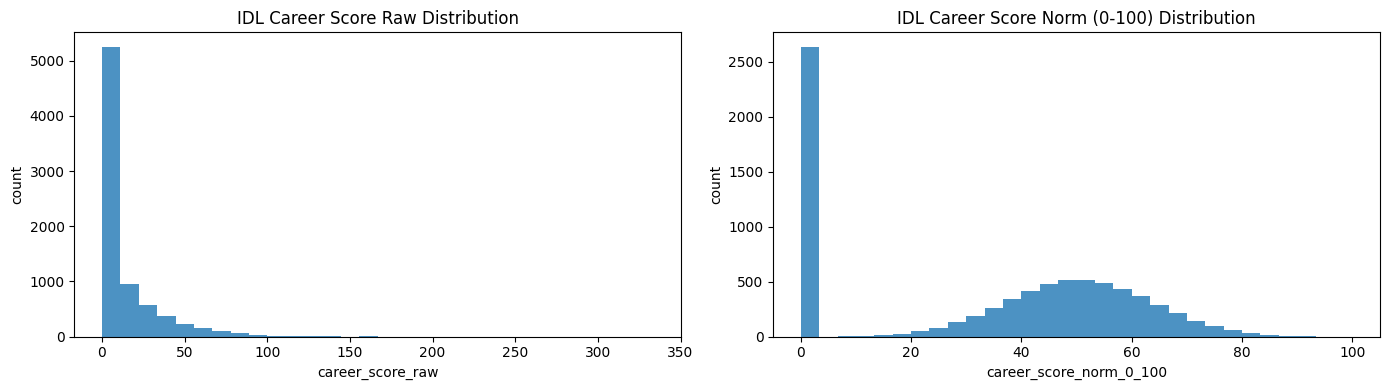


=== IDL top 10 players ===


,Player_ID,Player,schools_played,games_total,award_count,heisman_finish,career_score_raw,career_score_norm_0_100,component_pg_sos_norm,component_games_sos_norm,score_blend_pre_norm
690,aidan-hutchinson-1,Aidan Hutchinson,Michigan,43.0,6.0,2,327.995,100.0000,94.7383,72.2912,83.51475
178,derrick-brown-6,Derrick Brown,Auburn,53.0,3.0,0,179.825,96.1955,80.1127,82.7445,81.42860
76,christian-wilkins-1,Christian Wilkins,Clemson,58.0,1.0,0,158.830,94.3283,74.3012,87.3878,80.84450
22,tvondre-sweat-1,T'vondre Sweat,Texas,62.0,3.0,0,134.865,93.0597,66.7170,94.3663,80.54165
151,kyle-kennard-1,Kyle Kennard,Georgia Tech|South Carolina,54.0,4.0,0,233.590,92.0905,81.7580,78.1898,79.97390
5,akheem-mesidor-1,Akheem Mesidor,Miami (FL)|West Virginia,65.0,0.0,0,179.965,91.3024,71.0708,87.1011,79.08595
1565,jonathan-allen-1,Jonathan Allen,Alabama,30.0,9.0,7,333.725,90.6363,100.0000,58.0943,79.04715
967,rueben-bain-jr-1,Rueben Bain Jr.,Miami (FL),38.0,3.0,0,197.655,90.0581,85.9160,66.6617,76.28885
2451,jordan-davis-9,Jordan Davis,Georgia,22.0,5.0,9,159.440,89.5465,92.1043,57.2287,74.66650
578,jerzhan-newton-1,Jer'Zhan Newton,Illinois,45.0,2.0,0,170.015,89.0870,79.0635,69.7905,74.42700


In [111]:
# IDL scoring
IDL_SCORED = run_position_scoring("IDL", save_output=True, show_top_n=10)


=== SPEC score summary (raw) ===
count    4326.000
mean       18.987
std        41.946
min         0.000
10%         0.000
25%         0.000
50%         0.000
75%        15.400
90%        61.043
max       343.700
Name: career_score_raw, dtype: float64

=== SPEC score summary (normalized 0-100) ===
count    4326.000
mean       26.919
std        27.210
min         0.000
10%         0.000
25%         0.000
50%        28.863
75%        51.591
90%        62.966
max       100.000
Name: career_score_norm_0_100, dtype: float64


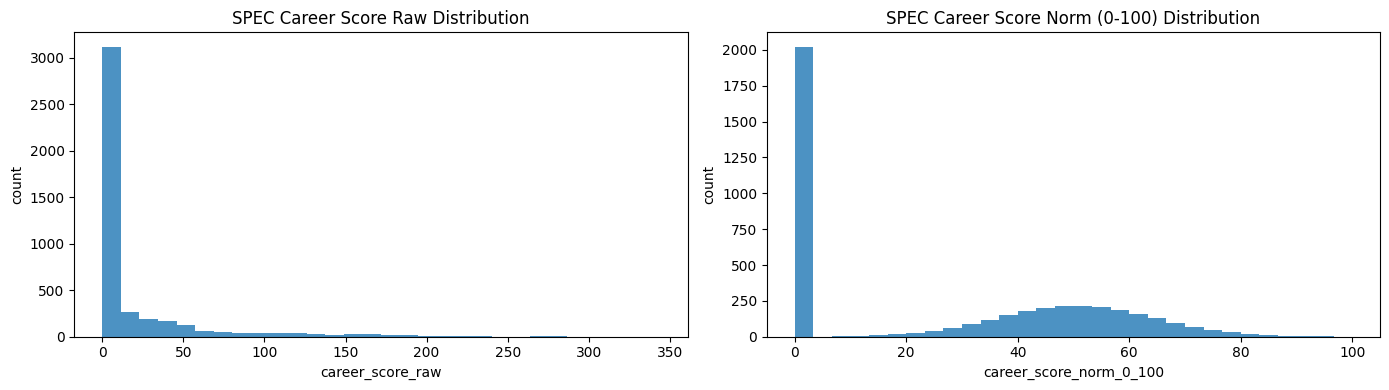


=== SPEC top 10 players ===


,Player_ID,Player,schools_played,games_total,award_count,heisman_finish,career_score_raw,career_score_norm_0_100,component_pg_sos_norm,component_games_sos_norm,score_blend_pre_norm
29,jake-moody-1,Jake Moody,Michigan,60.0,2.0,0,266.700,100.0000,83.3757,90.2627,86.81920
91,austin-seibert-1,Austin Seibert,Oklahoma,54.0,0.0,0,278.085,95.7383,90.3510,82.8102,86.58060
63,rodrigo-blankenship-1,Rodrigo Blankenship,Georgia,56.0,1.0,0,258.000,93.6337,83.9488,85.0570,84.50290
64,anders-carlson-1,Anders Carlson,Auburn,56.0,0.0,0,226.450,92.1981,79.2084,86.8349,83.02165
178,harrison-mevis-1,Harrison Mevis,Missouri,50.0,0.0,0,238.700,91.0980,85.2517,78.1442,81.69795
59,matt-coghlin-1,Matt Coghlin,Michigan State,57.0,0.0,0,211.400,90.2012,75.5229,87.7477,81.63530
103,damian-ramos-1,Damian Ramos,LSU,53.0,0.0,0,215.600,89.4415,78.5798,83.4686,81.02420
11,christopher-dunn-1,Christopher Dunn,North Carolina State,62.0,2.0,0,343.700,88.7807,82.8438,78.6742,80.75900
203,bert-auburn-1,Bert Auburn,Miami (FL)|Texas,49.0,0.0,0,205.800,88.1950,81.0227,80.4205,80.72160
28,andre-szmyt-1,Andre Szmyt,Syracuse,60.0,2.0,0,318.150,87.6682,82.3468,79.0126,80.67970


In [112]:
# SPEC scoring
SPEC_SCORED = run_position_scoring("SPEC", save_output=True, show_top_n=10)

In [113]:
bridge_df = pd.read_csv(name_match_path, dtype=str).fillna("")
bridge_df["recruit_id"] = bridge_df["recruit_id"].astype(str).str.strip()
bridge_df["sports_ref_id"] = bridge_df["sports_ref_id"].astype(str).str.strip()
bridge_df["team_match"] = safe_numeric(bridge_df.get("team_match", 0))
bridge_df["name_score"] = safe_numeric(bridge_df.get("name_score", 0))
bridge_df["year_diff"] = safe_numeric(bridge_df.get("year_diff", 99))
bridge_df["match_priority"] = bridge_df.get("match_strategy", "").map(lambda value: 1 if value == "PRIMARY_LAYER" else 0)

merge_diagnostics = []

for position in FINAL_POSITION_GROUPS:
    recruit_file = recruit_pos_dir / f"{position}_modeling.csv"
    if not recruit_file.exists():
        print(f"Skipping {position}: missing recruit positional file {recruit_file.name}")
        merge_diagnostics.append({"position": position, "recruit_rows": 0, "matched_rows": 0, "coverage_pct": 0.0})
        continue

    recruit_df = pd.read_csv(recruit_file, dtype=str).fillna("")
    recruit_df["player_id"] = recruit_df["player_id"].astype(str).str.strip()

    scored_df = scored_career_by_position.get(position)
    if scored_df is None or scored_df.empty:
        scored_path = final_output_dir / f"{position}_college_scored_targets.csv"
        if scored_path.exists():
            scored_df = pd.read_csv(scored_path, dtype=str).fillna("")
            print(f"Loaded scored targets from disk for {position}: {scored_path.name}")
        else:
            print(f"Skipping {position}: no in-memory scored table and no saved file {scored_path.name}")
            recruit_out = recruit_df.copy()
            recruit_out["target_career_score_0_100"] = pd.NA
            recruit_out_path = final_output_dir / f"{position}_modeling_with_target.csv"
            recruit_out.to_csv(recruit_out_path, index=False, encoding="utf-8-sig")
            merge_diagnostics.append({
                "position": position,
                "recruit_rows": int(len(recruit_out)),
                "matched_rows": 0,
                "coverage_pct": 0.0,
            })
            continue

    scored_df = scored_df.copy()
    scored_df["Player_ID"] = scored_df["Player_ID"].astype(str).str.strip()

    bridge_scored = bridge_df.merge(scored_df, left_on="sports_ref_id", right_on="Player_ID", how="inner")
    if "pos_norm" in bridge_scored.columns:
        bridge_scored = bridge_scored[bridge_scored["pos_norm"] == position].copy()

    if bridge_scored.empty:
        recruit_out = recruit_df.copy()
        recruit_out["target_career_score_0_100"] = pd.NA
        recruit_out_path = final_output_dir / f"{position}_modeling_with_target.csv"
        recruit_out.to_csv(recruit_out_path, index=False, encoding="utf-8-sig")
        merge_diagnostics.append({
            "position": position,
            "recruit_rows": int(len(recruit_out)),
            "matched_rows": 0,
            "coverage_pct": 0.0,
        })
        continue

    bridge_scored = bridge_scored.sort_values(
        by=["recruit_id", "team_match", "match_priority", "name_score", "year_diff"],
        ascending=[True, False, False, False, True],
    )
    bridge_best = bridge_scored.drop_duplicates(subset=["recruit_id"], keep="first")

    target_cols = [
        "recruit_id", "sports_ref_id", "match_strategy", "name_score", "team_match", "year_diff",
        "career_score_norm_0_100", "career_score_raw", "year_score_sum", "sos_season_weighted",
        "seasons_count", "games_total", "award_count", "heisman_finish", "schools_played", "latest_school"
    ]
    target_cols = [column for column in target_cols if column in bridge_best.columns]

    recruit_out = recruit_df.merge(bridge_best[target_cols], left_on="player_id", right_on="recruit_id", how="left")
    recruit_out = recruit_out.rename(columns={"career_score_norm_0_100": "target_career_score_0_100"})

    recruit_out_path = final_output_dir / f"{position}_modeling_with_target.csv"
    recruit_out.to_csv(recruit_out_path, index=False, encoding="utf-8-sig")

    matched_count = recruit_out["target_career_score_0_100"].notna().sum() if "target_career_score_0_100" in recruit_out.columns else 0
    coverage_pct = round((matched_count / len(recruit_out) * 100), 2) if len(recruit_out) else 0.0
    merge_diagnostics.append({
        "position": position,
        "recruit_rows": int(len(recruit_out)),
        "matched_rows": int(matched_count),
        "coverage_pct": coverage_pct,
    })

diagnostics_df = pd.DataFrame(merge_diagnostics)
diagnostics_path = final_output_dir / "target_merge_diagnostics.csv"
diagnostics_df.to_csv(diagnostics_path, index=False, encoding="utf-8-sig")

print(f"Saved diagnostics: {diagnostics_path}")
if not diagnostics_df.empty and "position" in diagnostics_df.columns:
    diagnostics_df = diagnostics_df.sort_values("position").reset_index(drop=True)
diagnostics_df

Saved diagnostics: x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\final\target_merge_diagnostics.csv


,position,recruit_rows,matched_rows,coverage_pct
0,DB,6803,4028,59.21
1,EDGE,3390,827,24.40
2,IDL,3278,1840,56.13
3,LB,4450,2397,53.87
4,OL,6607,4130,62.51
5,QB,2786,1414,50.75
6,RB,3181,1608,50.55
7,SPEC,728,570,78.30
8,TE,1942,1191,61.33
9,WR,5380,2858,53.12


In [114]:
# Get the min non-zero value for each position that was matched to a recruit
min_score_summary = []

for position in FINAL_POSITION_GROUPS:
    target_file = final_output_dir / f"{position}_modeling_with_target.csv"
    if not target_file.exists():
        continue
    
    df_temp = pd.read_csv(target_file, dtype=str)
    if "target_career_score_0_100" not in df_temp.columns:
        continue
        
    scores = pd.to_numeric(df_temp["target_career_score_0_100"], errors="coerce").dropna()
    active_scores = scores[scores > 0]
    
    if not active_scores.empty:
        min_score_summary.append({
            "position": position,
            "min_nonzero_score": active_scores.min(),
            "median_score": active_scores.median(),
            "max_score": active_scores.max(),
            "matched_count": len(active_scores)
        })
    else:
        min_score_summary.append({
            "position": position,
            "min_nonzero_score": np.nan,
            "median_score": np.nan,
            "max_score": np.nan,
            "matched_count": 0
        })
        
min_scores_df = pd.DataFrame(min_score_summary)
print("Summary of Non-Zero Match Scores by Position:")
display(min_scores_df.round(4))

Summary of Non-Zero Match Scores by Position:


,position,min_nonzero_score,median_score,max_score,matched_count
0,DB,4.5979,54.9807,100.0000,3144
1,EDGE,7.5697,52.4743,100.0000,583
2,IDL,10.3637,53.6028,96.1955,1369
3,LB,12.2030,54.6881,91.3976,1797
4,OL,26.3408,56.2592,100.0000,2597
5,QB,1.0000,52.3073,100.0000,881
6,RB,5.0408,55.0797,100.0000,1279
7,SPEC,1.0000,56.4032,95.7383,446
8,TE,1.0000,55.3329,100.0000,831
9,WR,6.6233,53.5994,100.0000,2131


In [115]:
# Quick output inventory
final_files = sorted(final_output_dir.glob("*.csv"))
print(f"Total files in final output: {len(final_files)}")
for file_path in final_files:
    print(file_path.name)

Total files in final output: 21
DB_college_scored_targets.csv
DB_modeling_with_target.csv
EDGE_college_scored_targets.csv
EDGE_modeling_with_target.csv
IDL_college_scored_targets.csv
IDL_modeling_with_target.csv
LB_college_scored_targets.csv
LB_modeling_with_target.csv
OL_college_scored_targets.csv
OL_modeling_with_target.csv
QB_college_scored_targets.csv
QB_modeling_with_target.csv
RB_college_scored_targets.csv
RB_modeling_with_target.csv
SPEC_college_scored_targets.csv
SPEC_modeling_with_target.csv
target_merge_diagnostics.csv
TE_college_scored_targets.csv
TE_modeling_with_target.csv
WR_college_scored_targets.csv
WR_modeling_with_target.csv
